In [1]:
%load_ext autoreload
%autoreload 2
import param_tool as pt
import os 
import numpy as np
from rdkit.Chem.Draw import IPythonConsole
import sys
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdFMCS
from typing import Callable
import psiresp
import nglview as nv
import MDAnalysis as mda
import glob
import pandas as pd
import json

import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, clear_output

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (600, 400)

/home/n_kristovsky/.conda/envs/topmol2/lib/python3.8/site-packages/psiresp/charge.py:282: FutureWarning: `symmetric_atoms_are_equivalent` will be set to False by default for now, as it is a new feature. It will be set to True by default in the future
  warnings.warn(


In [42]:
test = '[O-]C([C@H](CCCCNC(N)=[NH2+])[NH3+])=O'
test_chem = pt.smi_to_chem(test)
for atom in test_chem[0].GetAtoms():
    print(atom.GetAtomicNum())

8
6
6
6
6
6
6
7
6
7
7
7
8
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [67]:
def get_index_cherge_atoms(chem): 
    N_list = []
    O_list = []
    C_list = []
    H_list = []
    # test_chem[0]
    for atom in chem.GetAtoms():
        atom_charge = atom.GetAtomicNum()
        if atom_charge == 8:
            O_list.append(atom.GetIdx())
        elif atom_charge == 7:
            N_list.append(atom.GetIdx())
        elif atom_charge == 6:
            C_list.append(atom.GetIdx())
        elif atom_charge == 1:
            H_list.append(atom.GetIdx())
    if not len(N_list):
        N_list = False
    if not len(O_list):
        O_list = False
    if not len(C_list):
        C_list = False
    if not len(H_list):
        H_list = False
    return N_list, O_list, C_list, H_list
# print(N_list, O_list)
# pt.draw_mol_with_atom_index(test_chem[0])

In [40]:
smi_path_list = glob.glob('Lysine_*/molecules/substructure/*.smiles')
smi_path_list

['Lysine_2M/molecules/substructure/Lysine_2M.smiles',
 'Lysine_Malonyl/molecules/substructure/Lysine_malonyl.smiles',
 'Lysine_1M_ACC/molecules/substructure/Lysine_1M_ACC.smiles',
 'Lysine_prop/molecules/substructure/AKA_prop.smiles',
 'Lysine_Butyryl/molecules/substructure/Lysine_butyryl.smiles',
 'Lysine_Formyl/molecules/substructure/K_form.smiles',
 'Lysine_1M/molecules/substructure/Lysine_1M.smiles',
 'Lysine_ACC/molecules/substructure/K_ACC.smiles',
 'Lysine_Cro/molecules/substructure/Kcr_H.smiles',
 'Lysine_3M/molecules/substructure/Lysine_3M.smiles']

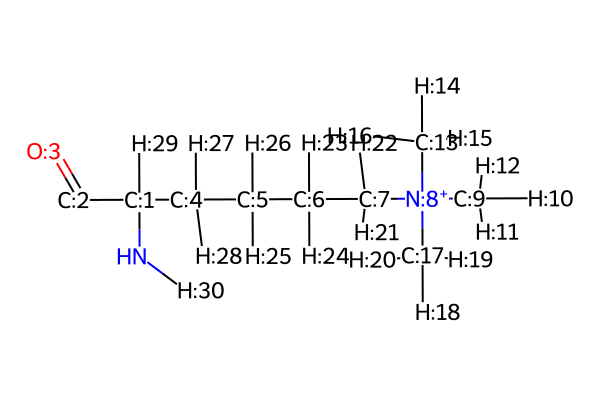

In [36]:
path = smi_path_list[6]
residue_name = path.split('/')[-1].split('.')[0]

smi = pt.read_file(path)
chek = pt.smi_to_chem(smi, addH=False, sanitize=False)
pt.draw_mol_with_atom_index(chek[residue_name])

In [18]:
chek

{0: <rdkit.Chem.rdchem.Mol at 0x7ffb582a4c10>}

In [68]:

Espaloma_data=[]
RESP_data=[]
residues_name = []

smiles_list = []
N_list = []
O_list = []
C_list = []
H_list = []
for path in smi_path_list:
    
    residue = path.split('/')[0]
    sub_name = path.split('/')[-1].split('.')[0]
    residues_name.append(residue)
    smiles = pt.read_file(path)
    smiles_list.append(smiles)
    mol_chem = pt.smi_to_chem(smiles, addH=False, sanitize=False)
    N, O, C, H = get_index_cherge_atoms(mol_chem[sub_name])
    N_list.append(N)
    O_list.append(O)
    C_list.append(C)
    H_list.append(H)

    with open(f'{residue}/AI_chrges_{sub_name}.json', 'r') as f:
        Espaloma_data.append(json.load(f))

    with open(f'{residue}/partial_charges.json', 'r') as f:
        RESP_data.append(json.load(f))


In [69]:
H_list

[[10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27],
 [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27],
 [12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28],
 [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28],
 [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
 [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22],
 [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
 [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
 [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
 [10, 11, 12, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]]

In [70]:
O_RESP = []
N_RESP = []
C_RESP = []
H_RESP = []
O_Espaloma = []
N_Espaloma = []
C_Espaloma = []
H_Espaloma = []
for N, O, C, H, RESP_charge, Espaloma_charge in zip(N_list, O_list, C_list, H_list, RESP_data, Espaloma_data):
    if N:
        N_RESP.append([RESP_charge[N_idx] for N_idx in N ] )
        N_Espaloma.append([Espaloma_charge[N_idx] for N_idx in N ])
    else:
        N_RESP.append(False)
        N_Espaloma.append(False)
    if O:
        O_RESP.append([RESP_charge[O_idx] for O_idx in O])
        O_Espaloma.append([Espaloma_charge[O_idx] for O_idx in O])
    else:
        O_RESP.append(False)
        O_Espaloma.append(False)
    if C:
        C_RESP.append([RESP_charge[C_idx] for C_idx in C ] )
        C_Espaloma.append([Espaloma_charge[C_idx] for C_idx in C ])
    else:
        C_RESP.append(False)
        C_Espaloma.append(False)
    if H:
        H_RESP.append([RESP_charge[H_idx] for H_idx in H])
        H_Espaloma.append([Espaloma_charge[H_idx] for H_idx in H])
    else:
        H_RESP.append(False)
        H_Espaloma.append(False)


In [71]:
H_RESP

[[0.1186,
  0.1186,
  0.1186,
  0.1161,
  0.1161,
  0.1161,
  0.2865,
  0.0716,
  0.0716,
  0.0541,
  0.0541,
  0.041,
  0.041,
  0.0244,
  0.0244,
  0.1426,
  0.2747],
 [0.2576,
  0.2576,
  0.3237,
  -0.1816,
  -0.1816,
  0.0621,
  0.0621,
  0.0103,
  0.0103,
  0.0362,
  0.0362,
  0.1426,
  0.2747],
 [0.116,
  0.116,
  0.116,
  0.0712,
  0.0712,
  0.0712,
  0.0565,
  0.0565,
  0.0254,
  0.0254,
  0.0105,
  0.0105,
  0.0391,
  0.0391,
  0.1426,
  0.2747],
 [0.1339,
  0.1339,
  0.1339,
  0.0151,
  0.0151,
  0.3356,
  0.0194,
  0.0194,
  0.0249,
  0.0249,
  0.0341,
  0.0341,
  0.0235,
  0.0235,
  0.1426,
  0.2747],
 [0.1396,
  0.1396,
  0.1396,
  0.0416,
  0.0416,
  0.1005,
  0.1005,
  0.3091,
  0.0892,
  0.0892,
  0.0621,
  0.0621,
  0.0103,
  0.0103,
  0.0362,
  0.0362,
  0.1426,
  0.2747],
 [0.0566,
  0.3099,
  0.0813,
  0.0813,
  0.0621,
  0.0621,
  0.0103,
  0.0103,
  0.0362,
  0.0362,
  0.1426,
  0.2747],
 [0.1135,
  0.1135,
  0.1135,
  0.2961,
  0.2961,
  0.0821,
  0.0821,
  0.010

In [73]:
calsulated_data = pd.DataFrame({
    'Residue': residues_name,
    'Smiles': smiles_list,
    'Espaloma': Espaloma_data,
    'RESP': RESP_data,
    
    'O_RESP': O_RESP,
    'N_RESP': N_RESP,
    'C_RESP': C_RESP,
    'H_RESP': H_RESP,
    'O_Espaloma': O_Espaloma,
    'N_Espaloma': N_Espaloma,
    'C_Espaloma': C_Espaloma,
    'H_Espaloma': H_Espaloma
})
calsulated_data

,Residue,Smiles,Espaloma,RESP,O_RESP,N_RESP,C_RESP,H_RESP,O_Espaloma,N_Espaloma,C_Espaloma,H_Espaloma
0,Lysine_2M,{'Lysine_2M': '[NH]([C:1]([CH:2]=[O:3])([C:4](...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0176, 0.0...",[-0.5894],"[-0.3479, 0.0323]","[-0.24, 0.7341, -0.0176, 0.042, -0.1021, -0.01...","[0.1186, 0.1186, 0.1186, 0.1161, 0.1161, 0.116...",[-0.5893999934196472],"[-0.34790000319480896, -0.6556916236877441]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.16266405582427979, 0.16266405582427979, 0.1..."
1,Lysine_Malonyl,{'Lysine_malonyl': '[NH]([C:1]([CH:2]=[O:3])([...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0094, 0.0...","[-0.5894, -0.5226, -0.792, -0.792]","[-0.3479, 0.5324]","[-0.24, 0.7341, -0.0094, 0.0187, -0.0479, -0.5...","[0.2576, 0.2576, 0.3237, -0.1816, -0.1816, 0.0...","[-0.5893999934196472, -0.6155163645744324, -0....","[-0.34790000319480896, -0.6293116211891174]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.1433624029159546, 0.1433624029159546, 0.350..."
2,Lysine_1M_ACC,{'Lysine_1M_ACC': '[NH]([C:1]([CH:2]=[O:3])([C...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0581, 0.0...","[-0.5894, -0.5814]","[-0.3479, -0.3039]","[-0.24, 0.7341, -0.0581, 0.0397, -0.019, -0.02...","[0.116, 0.116, 0.116, 0.0712, 0.0712, 0.0712, ...","[-0.5893999934196472, -0.5842599868774414]","[-0.34790000319480896, -0.510328471660614]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.1309618055820465, 0.13096179068088531, 0.13..."
3,Lysine_prop,{'AKA_prop': '[NH]([C:1]([CH:2]=[O:3])([C:4]([...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0581, 0.0...","[-0.5894, -0.4746]","[-0.3479, -0.5033]","[-0.24, 0.7341, -0.0581, 0.0397, -0.019, -0.02...","[0.1339, 0.1339, 0.1339, 0.0151, 0.0151, 0.335...","[-0.5893999934196472, -0.5538312196731567]","[-0.34790000319480896, -0.6229313015937805]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.1219402551651001, 0.1219402551651001, 0.121..."
4,Lysine_Butyryl,{'Lysine_butyryl': '[NH]([C:1]([CH:2]=[O:3])([...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0094, 0.0...","[-0.5894, -0.578]","[-0.3479, -0.6245]","[-0.24, 0.7341, -0.0094, 0.0187, -0.0479, -0.0...","[0.1396, 0.1396, 0.1396, 0.0416, 0.0416, 0.100...","[-0.5893999934196472, -0.5575700998306274]","[-0.34790000319480896, -0.625637412071228]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.11296914517879486, 0.11296914517879486, 0.1..."
5,Lysine_Formyl,{'K_form': '[NH]([C:1]([CH:2]=[O:3])([C:4]([C:...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, -0.0316, -0....","[-0.5894, -0.5325]","[-0.3479, -0.5786]","[-0.24, 0.7341, -0.0316, -0.0038, -0.0701, -0....","[0.0566, 0.3099, 0.0813, 0.0813, 0.0621, 0.062...","[-0.5893999934196472, -0.5102517604827881]","[-0.34790000319480896, -0.6041131019592285]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.1296933889389038, 0.3508141040802002, 0.101..."
6,Lysine_1M,{'Lysine_1M': '[NH]([C:1]([CH:2]=[O:3])([C:4](...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.3479, -0.24, 0.7341, -0.5894, 0.0111, 0.00...",[-0.5894],"[-0.3479, -0.1645]","[-0.24, 0.7341, 0.0111, 0.0012, 0.0316, 0.0236...","[0.1135, 0.1135, 0.1135, 0.2961, 0.2961, 0.082...",[-0.5893999934196472],"[-0.34790000319480896, -0.6957725882530212]","[-0.23999999463558197, 0.7340999841690063, -0....","[0.19370374083518982, 0.19370374083518982, 0.1..."
7,Lysine_ACC,{'K_ACC': '[NH]([C:1]([CH:2]=[O:3])([C:4]([C:5...,"[-0.34790000319480896, -0.23999999463558197, 0...","[-0.4157, 0.0028, 0.5972, -0.5679, -0.2323, 0....","[-0.5679, -0.6091]","[-0.4157, -0.703]","[0.0028, 0.5972, -0.2323, 0.1558, 0.066, -0.21...","[0.1241, 0.1241, 0.1241, 0.3789, 0.1407, 0.140...","[-0.5893999934196472, -0.6051116585731506]","[-0.34790000319480896

[NH3+]C(CO)C(O)=O


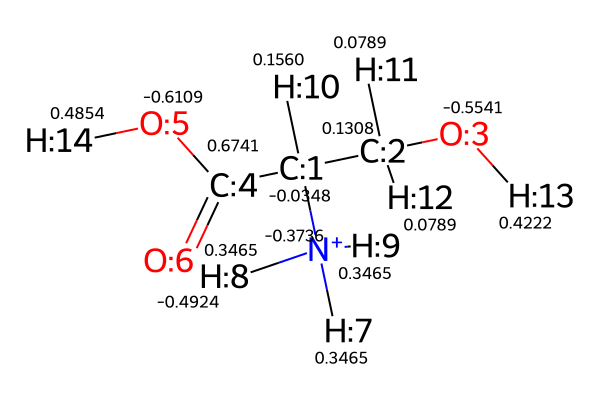

In [206]:
blowout = calsulated_data.iloc[26]['Smiles']
print(blowout)
blowout_chem = pt.smi_to_chem(blowout)
pt.draw_mol_with_atom_index(blowout_chem[0], calsulated_data.iloc[26]['RESP'], size=(600,400))
pt.draw_mol_with_atom_index(blowout_chem[0], calsulated_data.iloc[26]['RESP'], size=(600,400))

In [74]:
print(calsulated_data['RESP'].apply(sum).apply(round), calsulated_data['Espaloma'].apply(sum).apply(round))

0    1
1   -1
2    0
3    0
4    0
5    0
6    1
7    0
8    0
9    1
Name: RESP, dtype: int64 0    1
1   -1
2    0
3    0
4    0
5    0
6    1
7    0
8    0
9    1
Name: Espaloma, dtype: int64


In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [85]:
# Функция для расчета MMAE
def calculate_mae(df):
    mae_list = []
    for i in range(len(df)):
        resp_charges = df['RESP'][i]
        espaloma_charges = df['Espaloma'][i]
        if len(resp_charges) == len(espaloma_charges):
            mae = np.mean(np.abs(np.array(resp_charges) - np.array(espaloma_charges)))
            mae_list.append(mae)
    return mae_list

# Функция для расчета MMSE
def calculate_mse(df):
    mse_list = []
    for i in range(len(df)):
        resp_charges = df['RESP'][i]
        espaloma_charges = df['Espaloma'][i]
        if len(resp_charges) == len(espaloma_charges):
            mse = np.mean((np.array(resp_charges) - np.array(espaloma_charges)) ** 2)
            mse_list.append(mse)
    return mse_list

# Функция для расчета MAE для N и O
def calculate_mae_n_o(df):
    mae_o_list = []
    mae_n_list = []
    mae_c_list = []
    mae_h_list = []
    for i in range(len(df)):
        o_resp = df['O_RESP'][i]
        o_espaloma = df['O_Espaloma'][i]
        n_resp = df['N_RESP'][i]
        n_espaloma = df['N_Espaloma'][i]
        c_resp = df['C_RESP'][i]
        c_espaloma = df['C_Espaloma'][i]
        h_resp = df['H_RESP'][i]
        h_espaloma = df['H_Espaloma'][i]
        
        if isinstance(o_resp, list) and isinstance(o_espaloma, list):
            mae_o = np.mean(np.abs(np.array(o_resp) - np.array(o_espaloma)))
            mae_o_list.append(mae_o)
        
        if isinstance(n_resp, list) and isinstance(n_espaloma, list):
            mae_n = np.mean(np.abs(np.array(n_resp) - np.array(n_espaloma)))
            mae_n_list.append(mae_n)
        
        if isinstance(c_resp, list) and isinstance(c_espaloma, list):
            mae_c = np.mean(np.abs(np.array(c_resp) - np.array(c_espaloma)))
            mae_c_list.append(mae_c)
        
        if isinstance(h_resp, list) and isinstance(h_espaloma, list):
            mae_h = np.mean(np.abs(np.array(h_resp) - np.array(h_espaloma)))
            mae_h_list.append(mae_h)
    
    return mae_o_list, mae_n_list, mae_c_list, mae_h_list

def calculate_mse_n_o(df):
    mse_o_list = []
    mse_n_list = []
    mse_c_list = []
    mse_h_list = []
    for i in range(len(df)):
        o_resp = df['O_RESP'][i]
        o_espaloma = df['O_Espaloma'][i]
        n_resp = df['N_RESP'][i]
        n_espaloma = df['N_Espaloma'][i]
        c_resp = df['C_RESP'][i]
        c_espaloma = df['C_Espaloma'][i]
        h_resp = df['H_RESP'][i]
        h_espaloma = df['H_Espaloma'][i]
        
        # Расчет MSE для O_RESP и O_Espaloma
        if isinstance(o_resp, list) and isinstance(o_espaloma, list):
            mse_o = np.mean(np.square(np.array(o_resp) - np.array(o_espaloma)))
            mse_o_list.append(mse_o)
        
        # Расчет MSE для N_RESP и N_Espaloma
        if isinstance(n_resp, list) and isinstance(n_espaloma, list):
            mse_n = np.mean(np.square(np.array(n_resp) - np.array(n_espaloma)))
            mse_n_list.append(mse_n)
        
        if isinstance(c_resp, list) and isinstance(c_espaloma, list):
            mse_c = np.mean(np.square(np.array(c_resp) - np.array(c_espaloma)))
            mse_c_list.append(mse_c)
        
        # Расчет MSE для N_RESP и N_Espaloma
        if isinstance(h_resp, list) and isinstance(h_espaloma, list):
            mse_h = np.mean(np.square(np.array(h_resp) - np.array(h_espaloma)))
            mse_h_list.append(mse_h)
    return mse_o_list, mse_n_list, mse_c_list, mse_h_list

# Расчет MMAE
mae = calculate_mae(calsulated_data)
print(f"MMAE: {mae}")

# Расчет MMSE
mse = calculate_mse(calsulated_data)
print(f"MMSE: {mse}")

# Расчет MAE для N и O
mae_o, mae_n, mae_c, mae_h = calculate_mae_n_o(calsulated_data)
mse_o, mse_n, mse_c, mse_h = calculate_mse_n_o(calsulated_data)

print(f"MAE for O: {mae_o}")
print(f"MAE for N: {mae_n}")
print(f"MAE for O: {mse_o}")
print(f"MAE for N: {mse_n}")

MMAE: [0.08946931617270623, 0.15446919876177395, 0.0660380524783299, 0.07478103825665755, 0.07370240285564214, 0.06359042420452056, 0.10043930708086492, 0.101103051045537, 0.10266669865195949, 0.0869566074645327]
MMSE: [0.025029118540399936, 0.07757173702247384, 0.009353408385191966, 0.010861422085474238, 0.011123476120587044, 0.00821646543560177, 0.023271294464992005, 0.02074232972791416, 0.020951585642851614, 0.0273540533869633]
MAE for O: [6.580352818197355e-09, 0.04752673251628878, 0.0014299967288970983, 0.03961561312675477, 0.010214953374862668, 0.011124123048782353, 6.580352818197355e-09, 0.012744167423248298, 0.0356643171787262, 6.580352818197355e-09]
MAE for N: [0.34399581344127655, 0.5808558121919631, 0.10321423742771149, 0.05981565239429476, 0.0005687076330184726, 0.012756552577018743, 0.2656362957239151, 0.07192841289043425, 0.01866840956211091, 0.37805505030155184]
MAE for O: [4.330104321195787e-17, 0.004269402621462859, 4.0897624695900935e-06, 0.0031387930854480297, 0.0002

[H][C@@]12CC[C@H](N1C(=O)C2)C([O-])=O


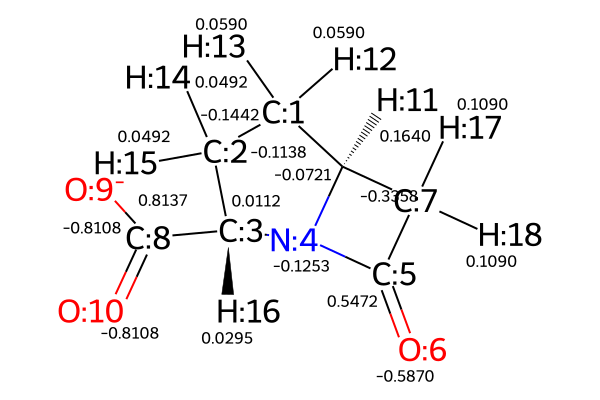

In [184]:
blowout = calsulated_data.iloc[21]['Smiles']
print(blowout)
blowout_chem = pt.smi_to_chem(blowout)
pt.draw_mol_with_atom_index(blowout_chem[0], calsulated_data.iloc[21]['RESP'])

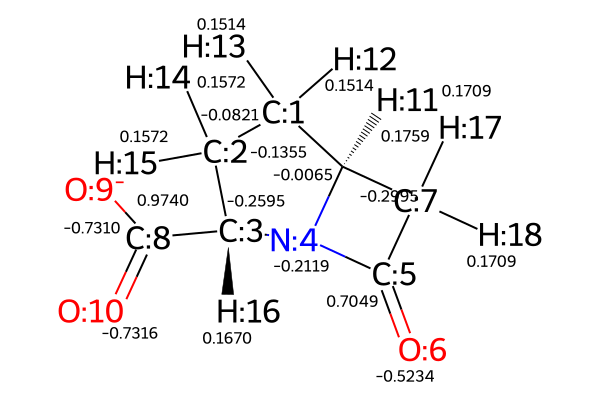

In [185]:
pt.draw_mol_with_atom_index(blowout_chem[0], calsulated_data.iloc[21]['Espaloma'])

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

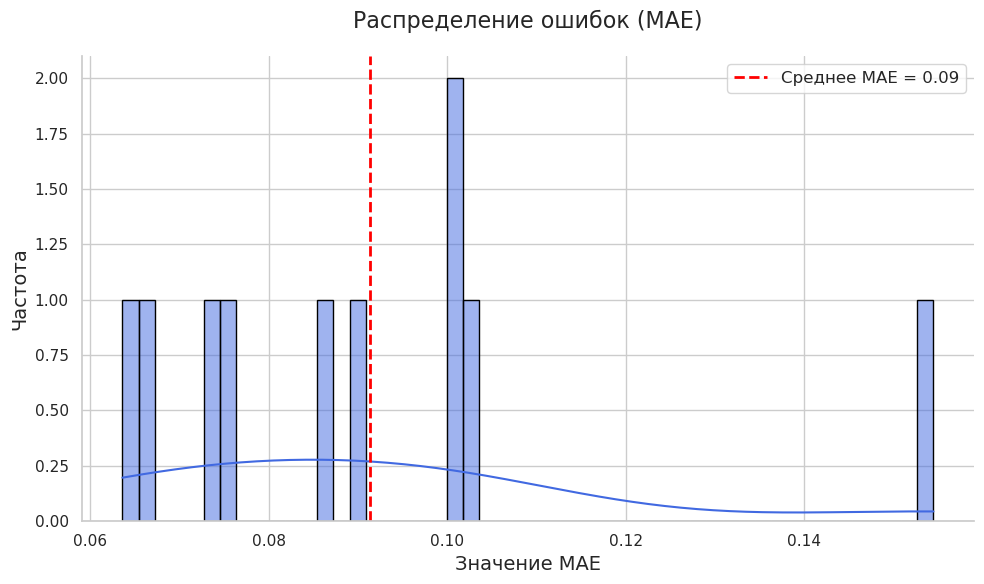

In [79]:
sns.set(style="whitegrid")  # Сетка и светлый фон
plt.figure(figsize=(10, 6))  # Размер графика

# Построение гистограммы
ax = sns.histplot(mae, bins=50, color='royalblue', kde=True, edgecolor='black')

# Добавление заголовка и подписей
plt.title('Распределение ошибок (MAE)', fontsize=16, pad=20)
plt.xlabel('Значение MAE', fontsize=14)
plt.ylabel('Частота', fontsize=14)

# Вывод среднего значения на графике
mean_mae = np.mean(mae)
ax.axvline(mean_mae, color='red', linestyle='--', linewidth=2, label=f'Среднее MAE = {mean_mae:.2f}')
plt.legend(fontsize=12)

# Улучшение отображения
sns.despine()  # Убираем лишние линии
plt.tight_layout()  # Автоматическая настройка отступов

# Показать график
plt.show()

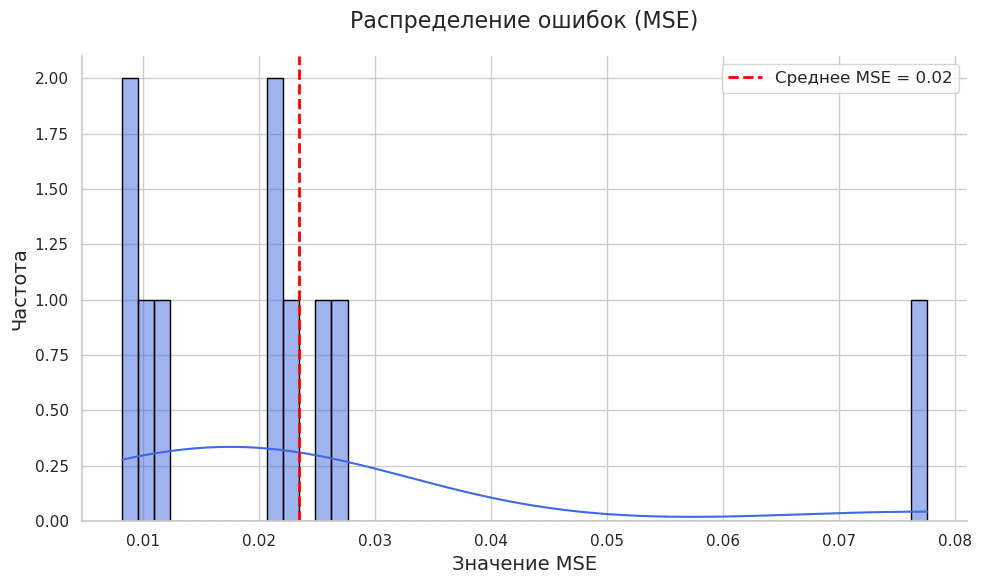

In [80]:
sns.set(style="whitegrid")  # Сетка и светлый фон
plt.figure(figsize=(10, 6))  # Размер графика

# Построение гистограммы
ax = sns.histplot(mse, bins=50, color='royalblue', kde=True, edgecolor='black')

# Добавление заголовка и подписей
plt.title('Распределение ошибок (MSE)', fontsize=16, pad=20)
plt.xlabel('Значение MSE', fontsize=14)
plt.ylabel('Частота', fontsize=14)

# Вывод среднего значения на графике
mean_mae = np.mean(mse)
ax.axvline(mean_mae, color='red', linestyle='--', linewidth=2, label=f'Среднее MSE = {mean_mae:.2f}')
plt.legend(fontsize=12)

# Улучшение отображения
sns.despine()  # Убираем лишние линии
plt.tight_layout()  # Автоматическая настройка отступов

# Показать график
plt.show()

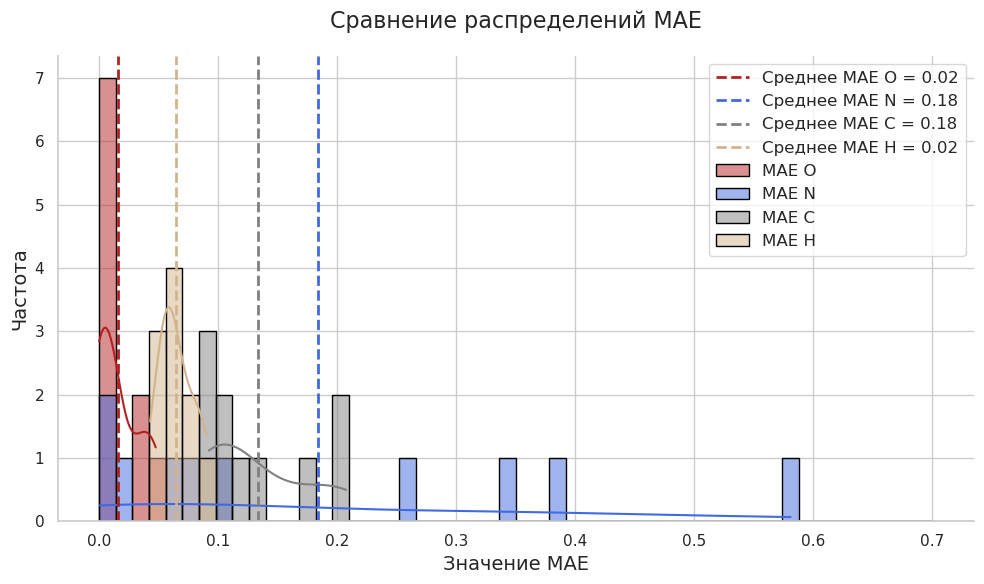

In [92]:
sns.set(style="whitegrid")  # Сетка и светлый фон
plt.figure(figsize=(10, 6))  # Размер графика

# Построение гистограмм
sns.histplot(mae_o, binrange=(0, 0.7),
             bins=50, color='firebrick', alpha=0.5, label='MAE O',edgecolor='black', kde=True)
sns.histplot(mae_n, binrange=(0, 0.7),
             bins=50, color='royalblue', alpha=0.5, label='MAE N',edgecolor='black', kde=True)
sns.histplot(mae_c, binrange=(0, 0.7),
             bins=50, color='gray', alpha=0.5, label='MAE C',edgecolor='black', kde=True)
sns.histplot(mae_h, binrange=(0, 0.7),
             bins=50, color='tan', alpha=0.5, label='MAE H',edgecolor='black', kde=True)

# Добавление заголовка и подписей
plt.title('Сравнение распределений MAE', fontsize=16, pad=20)
plt.xlabel('Значение MAE', fontsize=14)
plt.ylabel('Частота', fontsize=14)

# Вывод средних значений на графике
mean_mae_o = np.mean(mae_o)
mean_mae_n = np.mean(mae_n)
mean_mae_c = np.mean(mae_c)
mean_mae_h = np.mean(mae_h)
plt.axvline(mean_mae_o, color='firebrick', linestyle='--', linewidth=2, label=f'Среднее MAE O = {mean_mae_o:.2f}')
plt.axvline(mean_mae_n, color='royalblue', linestyle='--', linewidth=2, label=f'Среднее MAE N = {mean_mae_n:.2f}')

plt.axvline(mean_mae_c, color='gray', linestyle='--', linewidth=2, label=f'Среднее MAE C = {mean_mae_n:.2f}')
plt.axvline(mean_mae_h, color='tan', linestyle='--', linewidth=2, label=f'Среднее MAE H = {mean_mae_o:.2f}')

# Легенда
plt.legend(fontsize=12)

# Улучшение отображения
sns.despine()  # Убираем лишние линии
plt.tight_layout()  # Автоматическая настройка отступов

# Показать график
plt.show()

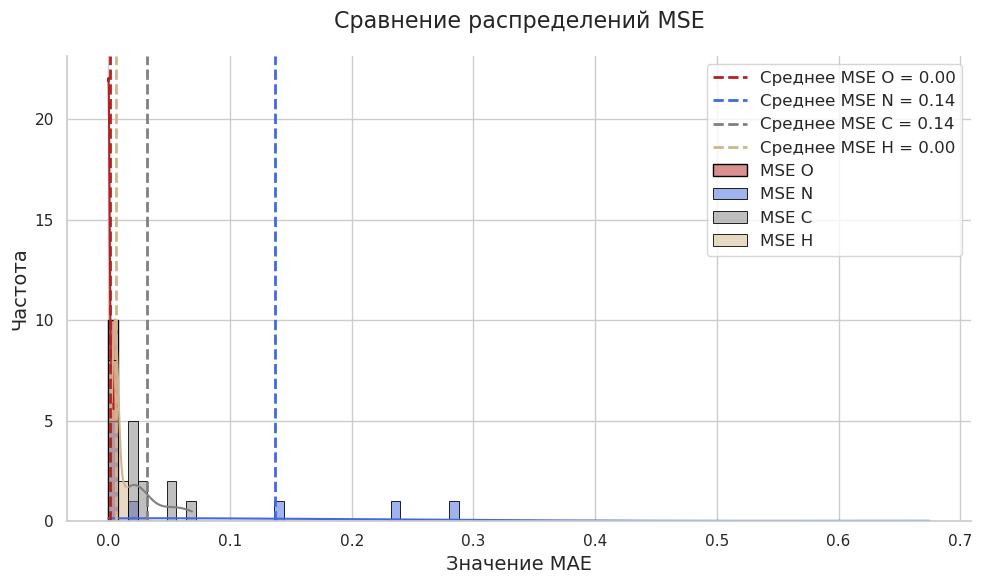

In [93]:
sns.set(style="whitegrid")  # Сетка и светлый фон
plt.figure(figsize=(10, 6))  # Размер графика

# Построение гистограмм
sns.histplot(mse_o, binrange=(0, 0.4), bins=50, color='firebrick', alpha=0.5,edgecolor='black', label='MSE O', kde=True)
sns.histplot(mse_n, binrange=(0, 0.4), bins=50, color='royalblue', alpha=0.5,edgecolor='black', label='MSE N', kde=True)
sns.histplot(mse_c, binrange=(0, 0.4), bins=50, color='gray', alpha=0.5,edgecolor='black', label='MSE C', kde=True)
sns.histplot(mse_h, binrange=(0, 0.4), bins=50, color='tan', alpha=0.5,edgecolor='black', label='MSE H', kde=True)

# Добавление заголовка и подписей
plt.title('Сравнение распределений MSE', fontsize=16, pad=20)
plt.xlabel('Значение MAE', fontsize=14)
plt.ylabel('Частота', fontsize=14)

# Вывод средних значений на графике
mean_mse_o = np.mean(mse_o)
mean_mse_n = np.mean(mse_n)
mean_mse_c = np.mean(mse_c)
mean_mse_h = np.mean(mse_h)
plt.axvline(mean_mse_o, color='firebrick', linestyle='--', linewidth=2, label=f'Среднее MSE O = {mean_mse_o:.2f}')
plt.axvline(mean_mse_n, color='royalblue', linestyle='--', linewidth=2, label=f'Среднее MSE N = {mean_mse_n:.2f}')

plt.axvline(mean_mse_c, color='gray', linestyle='--', linewidth=2, label=f'Среднее MSE C = {mean_mse_n:.2f}')
plt.axvline(mean_mse_h, color='tan', linestyle='--', linewidth=2, label=f'Среднее MSE H = {mean_mse_o:.2f}')

# Легенда
plt.legend(fontsize=12)

# Улучшение отображения
sns.despine()  # Убираем лишние линии
plt.tight_layout()  # Автоматическая настройка отступов

# Показать график
plt.show()